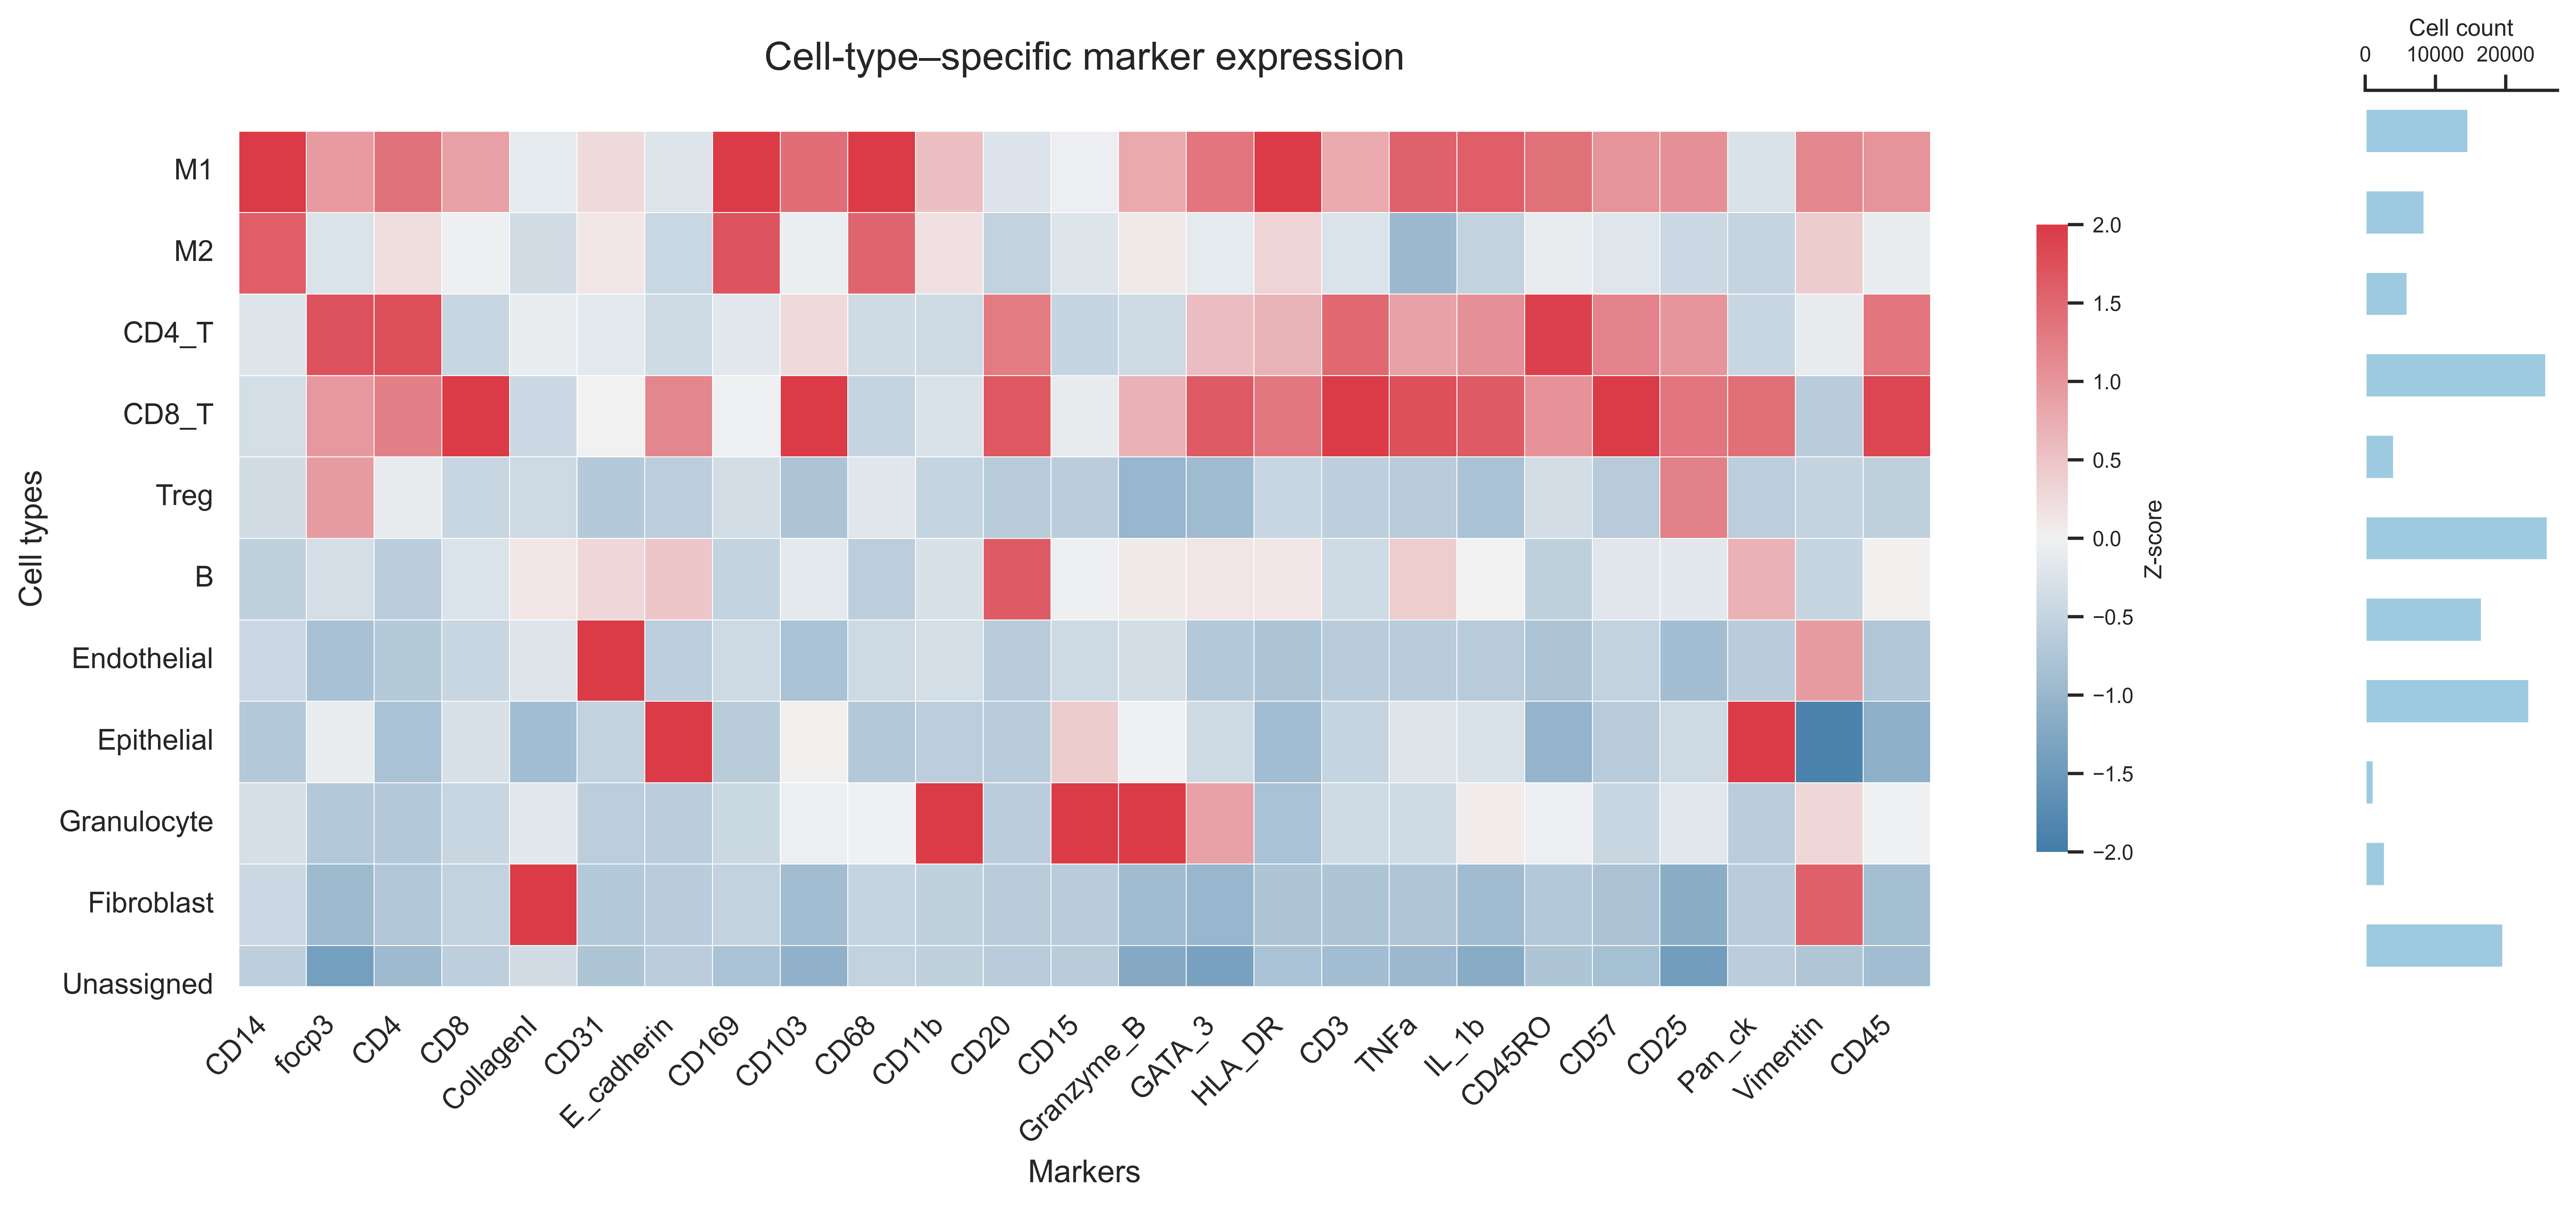

In [37]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import gridspec

# =========================
# 全局风格
# =========================
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 10,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 8.5,
    "ytick.labelsize": 9.5
})

sns.set_theme(style="white")  # 防止背景污染

# =========================
# 读取数据
# =========================
file_path = r"C:\Users\Li Chujia\Desktop\typexV2\annotated_cells_mixed.csv"
df = pd.read_csv(file_path)

selected_markers = [
    "CD14","focp3","CD4","CD8","CollagenI","CD31","E_cadherin",
    "CD169","CD103","CD68","CD11b","CD20","CD15","Granzyme_B",
    "GATA_3","HLA_DR","CD3","TNFa","IL_1b","CD45RO","CD57",
    "CD25","Pan_ck","Vimentin","CD45"
]

cell_order = [
    "M1","M2","CD4_T","CD8_T","Treg",
    "B","Endothelial","Epithelial","Granulocyte","Fibroblast","Unassigned"
]

cell_col = df.columns[0]
type_col = df.columns[-1]

# =========================
# 数据处理
# =========================
counts = df.groupby(type_col)[cell_col].count().rename("counts")
mean_by_type = df.groupby(type_col)[selected_markers].mean()

mean_by_type = mean_by_type.reindex(cell_order).dropna(how="all")
counts = counts.reindex(mean_by_type.index).fillna(0)  # 防止报错

# Z-score
Z = (mean_by_type - mean_by_type.mean(axis=0)) / mean_by_type.std(axis=0).replace(0, np.nan)
Z = Z.fillna(0.0).clip(-2, 2)

# =========================
# 作图
# =========================
fig = plt.figure(figsize=(14, 7), dpi=600, facecolor="white")  # ✅ 只保留这一行

gs = gridspec.GridSpec(
    nrows=1,
    ncols=2,
    width_ratios=[22, 2],
    wspace=0.01
)

# ===== Heatmap =====
ax_heat = plt.subplot(gs[0, 0])
ax_heat.set_facecolor("white")

cmap = sns.diverging_palette(240, 10, as_cmap=True)

hm = sns.heatmap(
    Z,
    ax=ax_heat,
    cmap=cmap,
    center=0,
    vmin=-2, vmax=2,
    cbar_kws={"label": "Z-score", "shrink": 0.7},
    linewidths=0.3,
    linecolor="white"
)

ax_heat.set_title("Cell-type–specific marker expression",fontsize=15, pad=8)
ax_heat.set_xlabel("Markers")
ax_heat.set_ylabel("Cell types")

ax_heat.set_xticklabels(ax_heat.get_xticklabels(), rotation=45, ha="right")
ax_heat.set_yticklabels(ax_heat.get_yticklabels(), rotation=0)

for spine in ax_heat.spines.values():
    spine.set_visible(False)

# ===== Counts =====
ax_bar = plt.subplot(gs[0, 1], sharey=ax_heat)
ax_bar.set_facecolor("white")

y_pos = np.arange(len(Z.index))

ax_bar.barh(
    y_pos,
    counts.values,
    color="#9ecae1",
    height=0.55
)

ax_bar.set_ylim(-0.5, len(Z.index) - 0.5)
ax_bar.invert_yaxis()

ax_bar.xaxis.set_ticks_position('top')
ax_bar.xaxis.set_label_position('top')
ax_bar.set_xlabel("Cell count", fontsize=9)

ax_bar.tick_params(axis='x', labelsize=8)
plt.setp(ax_bar.get_yticklabels(), visible=False)

for spine in ["right", "left", "bottom"]:
    ax_bar.spines[spine].set_visible(False)

# ===== Colorbar =====
cbar = hm.collections[0].colorbar
cbar.ax.tick_params(labelsize=8)
cbar.set_label("Z-score", fontsize=9)

# ===== 布局 =====
plt.subplots_adjust(left=0.08, right=0.96, top=0.90, bottom=0.22)

# ===== 保存 =====
plt.savefig("Fig1c_heatmap.tiff", dpi=600, bbox_inches="tight", facecolor="white")
plt.savefig("Fig1c_heatmap.pdf", bbox_inches="tight", facecolor="white")

plt.show()
plt.close()